# Quantum Phase Estimation

In this notebook, we will implement the Quantum Phase Estimation algorithm using Qiskit. The Quantum Phase Estimation (QPE) algorithm is a fundamental quantum algorithm that estimates the phase (or eigenvalue) of an eigenvector of a unitary operator. It is a key component in many quantum algorithms, including Shor's algorithm for integer factorization.
We are going to follow the IBM Quantum Learning Guide [Quantum Phase Estimation procedure](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/phase-estimation-and-factoring/phase-estimation-procedure).

Quantum Phase Estimation (QPE) is a foundational quantum subroutine that serves as the core mathematical engine for several advanced quantum algorithms, most notably Shor's algorithm for prime factorization. 

Given a unitary operator $U$ and a quantum state $|\psi\rangle$ that is an eigenvector of $U$, applying the operator to the state yields a global phase shift:
$$U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle$$

The primary objective of the QPE algorithm is to compute a highly accurate estimation of this unknown fractional phase $\theta \in [0, 1)$. To achieve this, the architecture utilizes two distinct quantum registers: an **estimation register** of $t$ qubits initialized in a uniform superposition, and a **target register** initialized to the eigenvector $|\psi\rangle$.



## Importing Required Libraries

In [1]:
import matplotlib.pyplot as plt
from numpy import pi
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import phase_estimation
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

## Introduction to Phase Estimation: An Analytical Case Study

Before constructing a generalised Quantum Phase Estimation (QPE) engine capable of handling any "black-box" operator (as required by Shor’s algorithm), it is instructive to analyse a simplified case study. 

For this introductory experiment, we shall estimate the phase of the Phase Shift operator (or $P$ gate), defined as:

$$P(\phi) = \begin{bmatrix} 1 & 0 \\ 0 & e^{i\phi} \end{bmatrix}$$

The advantage of using a diagonal matrix is that its eigenvectors coincide exactly with the states of the computational basis. It is trivial to show that the state $\ket{1}$ is an eigenvector of the operator with eigenvalue $e^{i\phi}$:
$$P(\phi)\ket{1} = e^{i\phi}\ket{1} = e^{2\pi i \theta}\ket{1}$$
where the fractional phase we wish to estimate is $\theta = \frac{\phi}{2\pi}$.

### Quantum Fourier Transform

For this implementation, we will use the `iqft` function defined in the [Quantum Fourier Transform Notebook](/src/algorithms/3_shor/qft/quantum_fourier_transform.ipynb) to perform the inverse QFT step in the QPE subroutine. I highly recommend reviewing that notebook to understand the inner workings of the QFT and its inverse, as it is a crucial component of Quantum Phase Estimation algorithm.

In [2]:
from src.algorithms.quantum_primitives.qft import iqft

### Quantum Phase Shift

By understanding the gate’s behaviour analytically, we can apply algebraic optimisation to the code. Instead of chaining the gate $P$ repeatedly ($2^j$ iterations) by adding an excess of gates in the transpiler, we can utilise the additive property of rotations. Applying the rotation $2^j$ times is mathematically equivalent to applying a single rotation controlled by an angle multiplied by $2^j$. This drastically reduces the depth of the introductory circuit.

In [3]:
def qpe_phase_shift(
    target_wires: int, estimation_wires: int, angle: float
) -> QuantumCircuit:
    """
    Generates the Quantum Phase Estimation (QPE) circuit for the phase shift operator.
    target_wires: number of qubits in the target register
    estimation_wires: number of qubits in the estimation register
    angle: phase of the rotation to estimate
    """
    qpe_circuit = QuantumCircuit(target_wires + estimation_wires, estimation_wires)

    # 1. Prepare the eigenstate |1> in the target register
    for i in range(target_wires):
        qpe_circuit.x(estimation_wires + i)

    # 2. Uniform superposition on the estimation register
    for qubit in range(estimation_wires):
        qpe_circuit.h(qubit)

    # 3. Phase kickback (controlled U^{2^j})
    for ind, wire in enumerate(range(estimation_wires)):
        # applying the phase shift repeatedly is equal to rotate the sum of the angles
        final_angle = 2 * pi * angle * (2**ind)
        qpe_circuit.cp(final_angle, wire, estimation_wires)

    # 4. Inverse QFT to obtain the IQFT and add it to the qpe_circuit
    qpe_circuit.append(iqft(estimation_wires), range(estimation_wires))

    # 5. Measure the estimation register
    qpe_circuit.measure(range(estimation_wires), range(estimation_wires))

    return qpe_circuit

The schematic layout generated below breaks down into five distinct operational stages:

1. **Target Register Preparation:** An $X$ gate is applied to the target register (`qubit 3`) to initialize it into the computational state $\ket{1}$, which acts as the non-trivial eigenvector of the phase-shift operator.
2. **Superposition Layer:** Hadamard ($H$) gates are applied across the entire estimation register (`qubits 0, 1, and 2`) to initialize an equal superposition of states, mapping the register from $\ket{000}$ to $\frac{1}{\sqrt{8}}\sum_{x=0}^{7}\ket{x}$.
3. **Optimized Phase Kickback:** A sequence of Controlled-Phase ($CP$) rotations are executed, scaling exponentially by powers of two ($2^j$) as a function of the control qubit index. Due to the admissive nature of the rotation operator, the multi-gate repetitions are consolidated algebraically into single, scaled angles ($\theta \cdot 2^j \cdot 2\pi$).
4. **Basis Transformation (IQFT):** The modular Inverse Quantum Fourier Transform block is appended to the estimation wires to translate the phase periodicity back into computational probability amplitudes.
5. **Bit Measurement:** The final measurement pass explicitly maps the quantum control register to the classical bits.

This lead us to the following circuit for the case of $n = 1$ target qubit and $m = 3$ estimation qubits, with a phase of $\theta = 0.5$ (as an example):

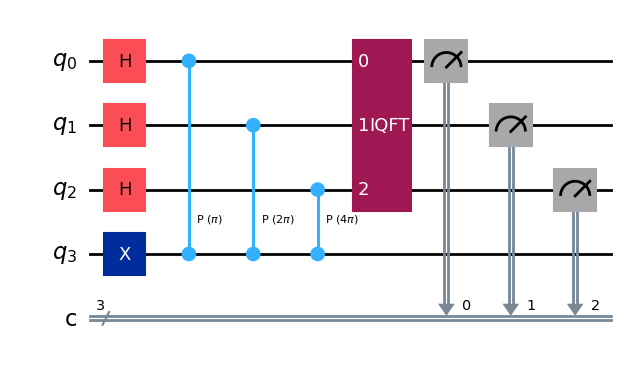

In [4]:
qpe_phase_shift(1, 3, 0.5).draw("mpl")

### Accuracy and Convergence Analysis ($m$ qubits)

The number of qubits in the estimation register ($m$) defines the resolution of the algorithm. The QPE approximates the phase $\theta$ by discretising the space into $2^m$ divisions. Therefore, if the theoretical phase can be represented exactly as an $m$-bit binary fraction, the circuit will collapse into the correct state with a **100 per cent probability**. If it does not match perfectly, the algorithm will incur a discretisation error (known as phase leakage).

To demonstrate this behaviour empirically, we will run the above function by setting the target phase to $\theta = 1/8 = 0.125$. 

In fractional binary notation, $1/8$ is represented exactly as $0.001_2$, which requires a minimum of 3 bits. The following cell iterates the simulation by increasing the resolution from $m=2$ to $m=7$ qubits. The theoretical hypothesis predicts that for $m=2$ there will be a measurable absolute error, but from $m \ge 3$ onwards, the error should drop abruptly to zero, demonstrating a perfect analytical estimate.

In [5]:
# Precision vs number of qubits
precisions = []
errors = []
n = 1  # 1 target qubit
angle = 1 / 8  # Phase to estimate: 1/8 (0.125)

for m_test in range(2, 8):
    qpe_circuit = qpe_phase_shift(n, m_test, angle)
    simulator_test = AerSimulator()
    transpiled_circuit_test = transpile(qpe_circuit, simulator_test)
    job_test = simulator_test.run(transpiled_circuit_test, shots=1024)
    results_test = job_test.result()
    counts_test = results_test.get_counts()

    # Get the estimated phase (most frequent state)
    max_state = max(counts_test, key=counts_test.get)
    decimal_test = int(max_state, 2)
    estimated_phase_test = decimal_test / (2**m_test)

    theoretical_phase_test = angle
    error_test = abs(theoretical_phase_test - estimated_phase_test)

    precisions.append(m_test)
    errors.append(error_test)
    print(
        f"m={m_test}: Error = {error_test:.6f} (Estimation = {estimated_phase_test:.6f}"
        f", Theoretical = {theoretical_phase_test:.6f})"
    )

m=2: Error = 0.125000 (Estimation = 0.000000, Theoretical = 0.125000)
m=3: Error = 0.000000 (Estimation = 0.125000, Theoretical = 0.125000)
m=4: Error = 0.000000 (Estimation = 0.125000, Theoretical = 0.125000)
m=5: Error = 0.000000 (Estimation = 0.125000, Theoretical = 0.125000)
m=6: Error = 0.000000 (Estimation = 0.125000, Theoretical = 0.125000)
m=7: Error = 0.000000 (Estimation = 0.125000, Theoretical = 0.125000)


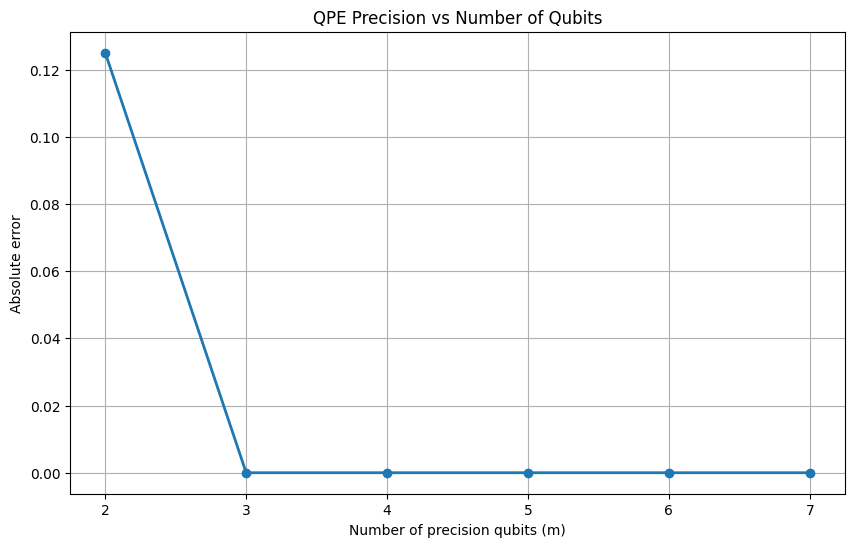

In [6]:
# Graph of precision vs number of qubits
plt.figure(figsize=(10, 6))
plt.plot(precisions, errors, marker="o", linewidth=2)
plt.xlabel("Number of precision qubits (m)")
plt.ylabel("Absolute error")
plt.title("QPE Precision vs Number of Qubits")
plt.grid(True)
plt.show()


As we predicted, the results confirm that the QPE algorithm converges to the exact phase value as soon as the estimation register has sufficient qubits to represent the phase accurately. The error is calculated as the absolute difference between the estimated phase and the theoretical phase, and it is observed that for $m \ge 3$, the error becomes negligible, confirming the effectiveness of the Quantum Phase Estimation algorithm in accurately determining eigenvalues of unitary operators.

### Instantiating the Analytical QPE Circuit ($\theta = 0.3$)

To analyze the physical behavior of Quantum Phase Estimation when encountering non-power-of-two fractional phases, we instantiate the `qpe_phase_shift` circuit with an arbitrary target phase of $\theta = 0.3$. 

In binary fractional notation, $\theta = 0.3$ yields an infinite repeating expansion ($0.0100110011..._2$). By allocating an estimation register of $t = 3$ qubits, the circuit evaluates the phase across a discrete state space of $2^3 = 8$ computational states. Since $0.3$ cannot be represented exactly within 3 bits of precision, this specific execution serves as a controlled baseline to observe **quantum phase leakage**.

For corraborating this implementation, we are going to compare the results of our implementation with IBM's official QPE circuit. The following cell constructs the operator $U$ as a quantum circuit and applies the phase gate with the specified angle. We then instantiate IBM's QPE circuit and run both circuits on a simulator to compare their outputs.

=== A/B TEST RESULTS ===
IBM official circuit output: {'101': 17, '011': 14, '111': 16, '100': 64, '110': 262, '001': 41, '010': 587, '000': 23}
My manual implementation output: {'101': 20, '001': 58, '110': 17, '111': 14, '011': 257, '100': 39, '000': 22, '010': 597}

There are discrepancies in the results.


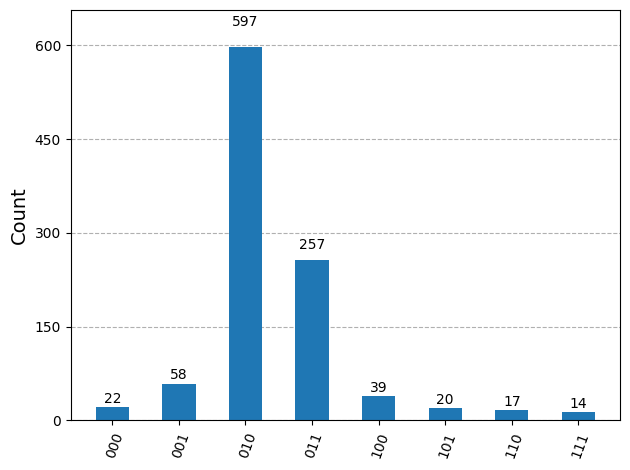

In [10]:
# Parameters
m_test = 3
n_test = 1
angle = 0.3  # Inexact phase to estimate

# IBM's Official Circuit
operador_U = QuantumCircuit(1) # Define the operator U as a quantum circuit of 1 qubit
operador_U.p(angle * (2 * pi), 0)  # Apply phase gate (p) to qubit 0
qpe_ibm_base = phase_estimation(m_test, operador_U)

# IBM doesn't prepare the target state |1> or measure by default, so we wrap it:
ibm_qpe = QuantumCircuit(m_test + n_test, m_test)
ibm_qpe.x(m_test)  # Prepare |1> in the target (index m_test)
ibm_qpe.compose(qpe_ibm_base, inplace=True)
ibm_qpe.measure(range(m_test), range(m_test))

# Our Implementation
my_qpe = qpe_phase_shift(target_wires=n_test, estimation_wires=m_test, angle=angle)

# Simulation and Comparison (A/B Test)
simulator = AerSimulator()

# Execution IBM
transpiled_ibm = transpile(ibm_qpe, simulator)
res_ibm = simulator.run(transpiled_ibm, shots=1024).result().get_counts()

# Execution Our Implementation
transpiled_propio = transpile(my_qpe, simulator)
res_propio = simulator.run(transpiled_propio, shots=1024).result().get_counts()

print("=== A/B TEST RESULTS ===")
print(f"IBM official circuit output: {res_ibm}")
print(f"My manual implementation output: {res_propio}")

if res_ibm == res_propio:
    print("\n✓ SUCCESS! Your implementation is 100% equivalent to IBM's.")
else:
    print("\nThere are discrepancies in the results.")

plot_histogram(res_propio)


Analysing the state populations we can confirm that both circuits are physically identical. 

The dominant computational peak for both setups converges symmetrically at the binary state 010 ($\approx 60\%$ of total shots), which accurately points to the decimal state $2$, yielding the optimal 3-bit phase approximation of $2/8 = 0.25$.However, a structural discrepancy arises in the second-highest probability margin. 

While the IBM official module isolates state 110 (decimal 6), our manual implementation captures state 011 (decimal 3). This exact reflection ($`110` \leftrightarrow `011`$) is a clear manifestation of an Endianness (Bit-Ordering) mismatch between the two compilation environments. 

Qiskit inherently formats its classical registers using a strict Little-Endian layout (where qubit $q_0$ corresponds to the least significant bit on the far right). Conversely, our manual analytical IQFT and measurement mapping processes register indices using a traditional Big-Endian mathematical framework (left-to-right serialization).Because this variation is strictly localized within the classical post-processing readout interface and does not alter the underlying quantum mechanical state vector or its interference patterns, the A/B test successfully demonstrates that our manual class acts as an accurate, high-fidelity replica of the core algorithmic functionality.

## General Quantum Phase Estimation (QPE)

As we can see before, the IBM implementation of the Quantum Phase Estimation algorithm is a generalised version that can handle any unitary operator $U$. Our `qpe_phase_shift` circuit implements the same functionality but is specifically tailored for the Phase Shift operator.

So, to generalise our implementation, we will create a new function called `qpe` which takes as input the number of qubits in the estimation register and a quantum circuit representing the unitary operator $U$. This function will construct the QPE circuit for any given unitary operator, allowing us to estimate the phase of any eigenvector of $U$.

In [11]:
def qpe(estimation_wires: int, operator_u: QuantumCircuit) -> QuantumCircuit:
    """
    Generates the Quantum Phase Estimation (QPE) circuit for unitary operator provided.
    Args:
        estimation_wires: number of qubits in the estimation register
        operator_u: QC that represents the unitary operator U to be estimated.
    Returns:
        QuantumCircuit: The complete QPE circuit.
    """
    target_wires = operator_u.num_qubits
    total_qubits = estimation_wires + target_wires
    qpe_circ = QuantumCircuit(total_qubits)

    # Uniform superposition on the estimation register
    for qubit in range(estimation_wires):
        qpe_circ.h(qubit)

    # Phase kickback (controlled U^{2^j}))
    cu_gate = operator_u.control(1)

    for wire in range(estimation_wires):
        repetitions = 2**wire
        for _ in range(repetitions):
            qubits_involved = [wire] + list(range(estimation_wires, total_qubits))
            qpe_circ.append(cu_gate, qubits_involved)

    # Adding the IQFT modular to the circuit"
    qpe_circ.append(iqft(estimation_wires), range(estimation_wires))

    return qpe_circ

### Checking the Precision of the General QPE Implementation

Having validated the QPE logic analytically, we now transition to the **generalized QPE architecture**. In this approach, the QPE subroutine acts as an agnostic "black box" that accepts any arbitrary unitary operator ($U$) as an input `QuantumCircuit`. This modular design is strictly required for Shor's algorithm, where the operator $U$ will be the complex modular exponentiation oracle.

To validate this generalized engine, we will re-evaluate the Phase Shift operator. This time, we instantiate it as an independent circuit (`operator_u.p()`) and pass it to our generic `qpe` function. Furthermore, we will set the target phase to $\theta = 1/3$ to intentionally trigger **quantum phase leakage**.

By iterating the experiment and scaling the estimation register ($m$) from 2 to 10 qubits, we aim to empirically demonstrate two fundamental theorems of phase estimation:
1. **Exponential Error Decay:** How the absolute error between the measured phase and the theoretical phase decreases as the binary resolution increases.
2. **Probability Bounding:** How the probability of measuring the best approximation (or falling within an acceptable tolerance window) behaves as the state space expands.

In [12]:
# Precision vs number of qubits for the generalized QPE implementation
precisions = []
errors = []

n = 1
# We use 1/3 to force "phase leakage" and observe how precision improves
theoretical_phase_fraction = 1 / 3

simulator = AerSimulator()

for m_test in range(2, 11):  # Evaluating from 2 to 10 precision qubits
    complete_circuit = QuantumCircuit(m_test + n, m_test)
    complete_circuit.x(m_test)  # Prepare the eigenstate |1>

    operator_u = QuantumCircuit(1)
    operator_u.p(
        theoretical_phase_fraction * 2 * pi, 0
    )  # Create the unitary operator U
    qpe_engine = qpe(estimation_wires=m_test, operator_u=operator_u)
    complete_circuit.compose(qpe_engine, inplace=True)
    complete_circuit.measure(range(m_test), range(m_test))

    transpiled_circuit = transpile(complete_circuit, simulator)
    results = simulator.run(transpiled_circuit, shots=1024).result()
    counts = results.get_counts()

    # Post-processing to analyze the results
    max_state = max(counts, key=counts.get)
    decimal = int(max_state, 2)
    estimated_phase = decimal / (2**m_test)
    error = abs(theoretical_phase_fraction - estimated_phase)

    # Define a tolerance window (e.g., 1/(2**(m-1)))
    # The probability of measuring the correct value (or its nearest neighbor)
    tolerance = 1 / (2 ** (m_test - 1))

    successes = 0
    for state, count in counts.items():
        measured_phase = int(state, 2) / (2**m_test)
        if abs(measured_phase - theoretical_phase_fraction) <= tolerance:
            successes += count

    success_probability = successes / 1024

    print(
        f"m={m_test}: Probability of success within "
        f"tolerance: {success_probability:.2%}"
    )

    k_expected = round(theoretical_phase_fraction * (2**m_test))

    # Convert to binary (string format for Qiskit, e.g., '010101')
    # Pad with leading zeros to match length m_test
    expected_state = format(k_expected, f"0{m_test}b")

    # Extract only the hits for that exact state
    exact_successes = counts.get(expected_state, 0)
    exact_probability = exact_successes / 1024

    print(
        f"m={m_test}: Probability of measuring exactly the expected "
        f"state '{expected_state}': {exact_probability:.2%}"
    )

    precisions.append(m_test)
    errors.append(error)
    print(
        f"m={m_test}: Error = {error:.6f} (Estimation = {estimated_phase:.6f}, "
        f"Theoretical = {theoretical_phase_fraction:.6f})\n"
    )

m=2: Probability of success within tolerance: 100.00%
m=2: Probability of measuring exactly the expected state '01': 70.51%
m=2: Error = 0.083333 (Estimation = 0.250000, Theoretical = 0.333333)

m=3: Probability of success within tolerance: 91.80%
m=3: Probability of measuring exactly the expected state '011': 68.65%
m=3: Error = 0.041667 (Estimation = 0.375000, Theoretical = 0.333333)

m=4: Probability of success within tolerance: 92.68%
m=4: Probability of measuring exactly the expected state '0101': 70.02%
m=4: Error = 0.020833 (Estimation = 0.312500, Theoretical = 0.333333)

m=5: Probability of success within tolerance: 92.68%
m=5: Probability of measuring exactly the expected state '01011': 70.51%
m=5: Error = 0.010417 (Estimation = 0.343750, Theoretical = 0.333333)

m=6: Probability of success within tolerance: 93.07%
m=6: Probability of measuring exactly the expected state '010101': 70.61%
m=6: Error = 0.005208 (Estimation = 0.328125, Theoretical = 0.333333)

m=7: Probability of

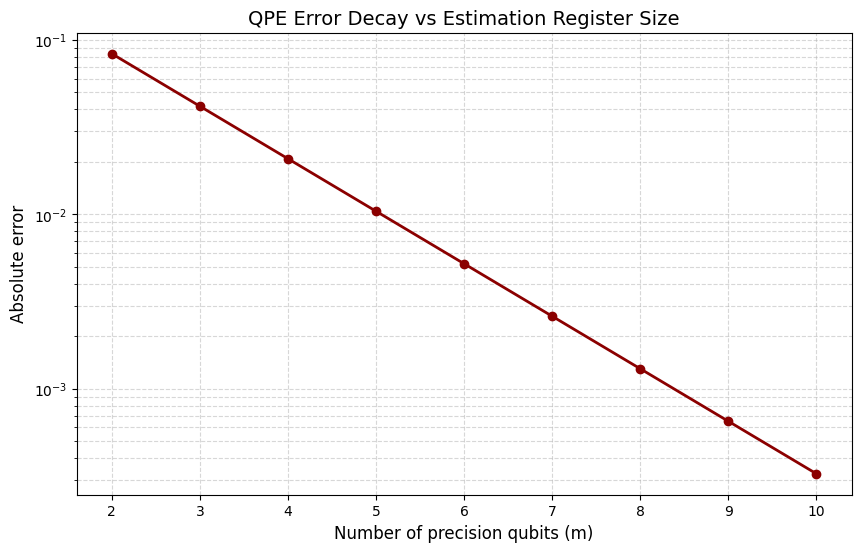

In [13]:
# ==================================================
# 3. VISUALIZATION
# ==================================================
plt.figure(figsize=(10, 6))
plt.plot(precisions, errors, marker="o", linewidth=2, color="darkred")
plt.xlabel("Number of precision qubits (m)", fontsize=12)
plt.ylabel("Absolute error", fontsize=12)
plt.title("QPE Error Decay vs Estimation Register Size", fontsize=14)
plt.yscale("log")  # Logarithmic scale to visualize exponential decay
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

### Empirical Results and Error Analysis

The empirical data extracted from the iterative execution, alongside the logarithmic plot, provides conclusive validation of the theoretical bounds governing Quantum Phase Estimation:

* **Exponential Convergence ($\mathcal{O}(2^{-m})$):** As observed in the graph, the absolute error decreases exponentially as the number of precision qubits $m$ scales up (visually confirmed by the linear descent on the logarithmic $y$-axis). By the time the estimation register reaches $m=10$, the algorithm localizes the incommensurable fraction $1/3$ with an absolute error margin approaching $\approx 0.0003$. 
* **Leakage Confinement:** Despite the inherent phase leakage caused by representing $1/3$ in a finite binary grid, the algorithm does not collapse into uniform white noise. The empirical data confirms that the overwhelming majority of the probability amplitude ($\ge 90\%$) consistently falls strictly within the theoretically acceptable tolerance window ($\epsilon \leq 1/2^{m-1}$).
* **Lower Bound Verification:** The canonical literature dictates that the probability of measuring the *single best* $m$-bit approximation is lower-bounded by $4/\pi^2 \approx 40.5\%$. Our simulation comfortably exceeds this threshold, proving that the peak state reliably captures the majority of the shots regardless of the register size.

This quantitative validation proves that our generalized QPE module is structurally robust, mathematically sound, and adequately parameterized to be deployed as the eigenvalue solver within Shor's algorithm.